In [31]:
#!pip install "numpy>=1.17.3,<1.25.0" --upgrade

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

Ukupan broj oglasa: 4143
-------------------------------------------------------------
Prihvaćeni oglasi: 2210 (53.34%)
Odbijeni oglasi: 1933 (46.66%)


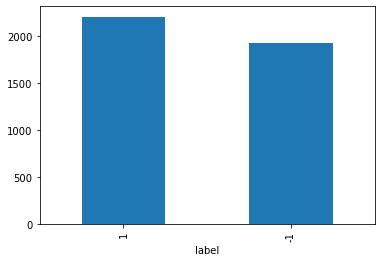

-------------------------------------------------------------
Broj jedinstvenih tokena: 54877
Sačuvan fajl: 'data/farm-ads.csv'



In [2]:
raw_data_path="data/farm-ads"
labels = []
texts = []

with open(raw_data_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        
        if not parts:
            continue
        # Prva reč u liniji je labela (1 ili -1)
        labels.append(int(parts[0]))
        
        #sve ostale reci su tekst dokumenta
        texts.append(" ".join(parts[1:]))

# Formiranje DataFrame-a
df = pd.DataFrame({
    "label": labels, 
    "text": texts
})


print("Ukupan broj oglasa:", len(df))
print("-------------------------------------------------------------")
class_counts = df["label"].value_counts()

print(f"Prihvaćeni oglasi: {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Odbijeni oglasi: {class_counts[-1]} ({class_counts[-1]/len(df)*100:.2f}%)")
df["label"].value_counts().plot(kind="bar")
plt.show()

#da prebrojimo koliko jedinstvenih tokena ima, tj velicina vokabulara
tokens = set()

for text in df["text"]:
    tokens.update(text.split())

print("-------------------------------------------------------------")
print("Broj jedinstvenih tokena:", len(tokens))


#preprocesiranje
def clean_text(text):
    # Svođenje na mala slova
    text = text.lower()
    # Uklanjanje višestrukih razmaka
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Primenjujemo čišćenje
df["cleaned_text"] = df["text"].apply(clean_text)

# Sačuvajmo polaznu verziju skupa podataka u obliku csv fajla
df.to_csv("data/farm-ads.csv", index=False)
print("Sačuvan fajl: 'data/farm-ads.csv'\n")


#podela na trening i test
X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"], 
    df["label"], 
    test_size=0.2, 
    random_state=42, 
    stratify=df["label"]  # Zadržavamo isti proportsionalni odnos klasa
)


In [3]:
#vektorizacija:
from sklearn.feature_extraction.text import CountVectorizer

#moramo da kažemo vectorizeru da je crtica deo tokena
vectorizer = CountVectorizer(
    token_pattern=r"(?u)\b[\w-]+\b",
    min_df=2
)

X_train_tf = vectorizer.fit_transform(X_train)
print(X_train_tf.shape)

(3314, 24307)


In [4]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()
# postojecu sparse matricu transformisemo u tf-idf matricu
X_train_tfidf = tfidf_transformer.fit_transform(X_train_tf)
X_test_tf = vectorizer.transform(X_test)
X_test_tfidf = tfidf_transformer.transform(X_test_tf)

print("Dimenzije TF-IDF matrice:", X_train_tfidf.shape)

Dimenzije TF-IDF matrice: (3314, 24307)


In [5]:
# Nazivi tokena
reci = vectorizer.get_feature_names_out()

# Uzimamo prvih nekoliko dokumenata
tfidf_prikaz = X_train_tfidf[:5]

# Pretvaramo u DataFrame
prikaz_tfidf_df = pd.DataFrame(
    tfidf_prikaz.toarray(),
    columns=reci
)

# Prikaz samo tokena koji imaju neku vrednost u ovih 5 dokumenata
prikaz_tfidf_df = prikaz_tfidf_df.loc[:, (prikaz_tfidf_df != 0).any(axis=0)].round(3)

prikaz_tfidf_df.iloc[:, :15]

,accent,accept,accessory,account,accurate,action,ad,ad-aatb,ad-agent,ad-agriculture,ad-bunny,ad-call,ad-com,ad-company,ad-compare
0,0.000,0.000,0.000,0.000,0.00,0.00,0.000,0.000,0.000,0.000,0.000,0.067,0.000,0.000,0.000
1,0.035,0.000,0.019,0.000,0.01,0.01,0.000,0.000,0.000,0.000,0.016,0.000,0.000,0.000,0.013
2,0.000,0.034,0.000,0.013,0.00,0.00,0.000,0.037,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.000,0.00,0.00,0.004,0.000,0.013,0.019,0.000,0.000,0.004,0.011,0.000
4,0.000,0.000,0.000,0.000,0.00,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.029,0.000,0.000


In [6]:
%matplotlib notebook

<IPython.core.display.Javascript object>


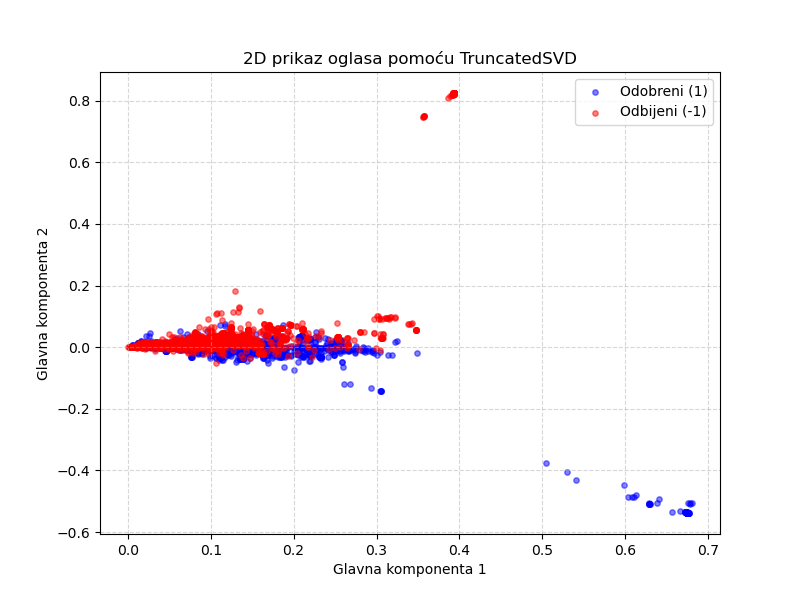

In [7]:
#2D vizuelizacija
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# 1. Smanjujemo našu veliku TF-IDF matricu na samo 2 glavne komponente
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_train_2d = svd_2d.fit_transform(X_train_tfidf)

# Pakujemo u DataFrame samo radi lakšeg iscrtavanja grafika
df_2d = pd.DataFrame(X_train_2d, columns=['Komponenta 1', 'Komponenta 2'])
df_2d['label'] = y_train.values

# 2. Kreiranje grafika
plt.figure(figsize=(8, 6))

# Razdvajamo klase da bismo ih obojili različito
odobreni = df_2d[df_2d['label'] == 1]
odbijeni = df_2d[df_2d['label'] == -1]

plt.scatter(odobreni['Komponenta 1'], odobreni['Komponenta 2'], color='blue', alpha=0.5, label='Odobreni (1)', s=15)
plt.scatter(odbijeni['Komponenta 1'], odbijeni['Komponenta 2'], color='red', alpha=0.5, label='Odbijeni (-1)', s=15)

plt.title('2D prikaz oglasa pomoću TruncatedSVD')
plt.xlabel('Glavna komponenta 1')
plt.ylabel('Glavna komponenta 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Prikazujemo grafik
plt.show()

<IPython.core.display.Javascript object>


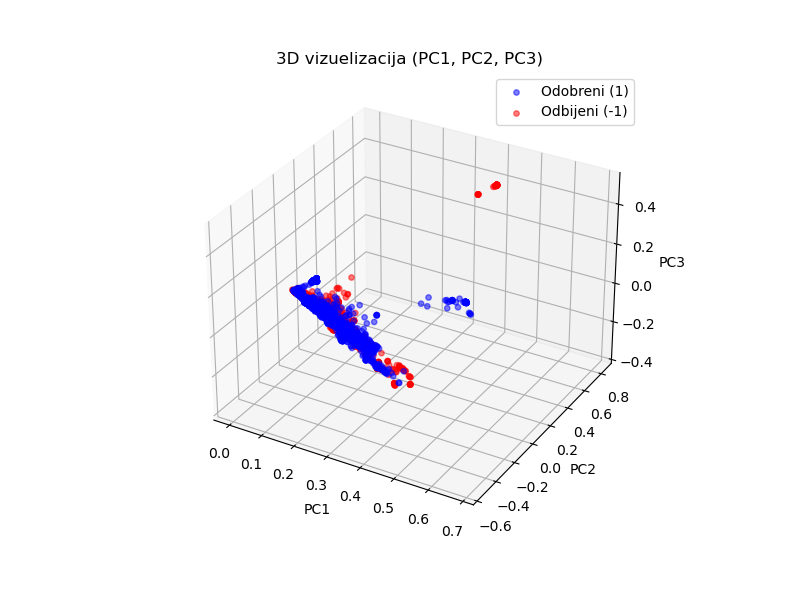

In [8]:
#3D vizuelizacija
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

svd_3d = TruncatedSVD(n_components=3, random_state=42)
X_train_3d = svd_3d.fit_transform(X_train_tfidf)

# Pravimo novi DataFrame sa eksplicitnim nazivima kolona
df_3d_prikaz = pd.DataFrame(X_train_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d_prikaz['label'] = y_train.values

# Delimo na odobrene i odbijene
odobreni_3d = df_3d_prikaz[df_3d_prikaz['label'] == 1]
odbijeni_3d = df_3d_prikaz[df_3d_prikaz['label'] == -1]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Koristimo naše ispravno mapirane DataFrame-ove
ax.scatter(odobreni_3d['PC1'], odobreni_3d['PC2'], odobreni_3d['PC3'], color='blue', alpha=0.5, label='Odobreni (1)', s=15)
ax.scatter(odbijeni_3d['PC1'], odbijeni_3d['PC2'], odbijeni_3d['PC3'], color='red', alpha=0.5, label='Odbijeni (-1)', s=15)

ax.set_title('3D vizuelizacija (PC1, PC2, PC3)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()

plt.show()

In [9]:
#redukcija dimenzionalnosti

#chi2
#bira vec postojece kolone

from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

original_features = X_train_tfidf.shape[1]
print(f"Originalni broj atributa: {original_features}")

k_values = [10, 100, 500, 1000, 3000, 5000, 10000, 20000]

# Čuvanje redukovanih matrica
chi2_train = {}
chi2_test = {}

# Čuvanje dodatnih informacija
chi2_selectors = {}
chi2_features = {}
chi2_scores = {}

summary = []

feature_names = vectorizer.get_feature_names_out()

for k in k_values:

    selector = SelectKBest(score_func=chi2, k=k)

    X_train_new = selector.fit_transform(X_train_tfidf, y_train)
    X_test_new = selector.transform(X_test_tfidf)

    # Čuvanje matrica
    chi2_train[k] = X_train_new
    chi2_test[k] = X_test_new

    # Čuvanje selektora
    chi2_selectors[k] = selector

    # Čuvanje tokena i njihovih χ² vrednosti
    chi2_features[k] = feature_names[selector.get_support()]
    chi2_scores[k] = selector.scores_[selector.get_support()]

    reduction = (1 - k / original_features) * 100

    summary.append({
    "k": k,
    "Broj atributa": X_train_new.shape[1],
    "Zadržano (%)": round(100 * k / original_features, 2),
    "Redukcija (%)": round(reduction, 2)
})
    
summary_df = pd.DataFrame(summary)
summary_df

Originalni broj atributa: 24307


,k,Broj atributa,Zadržano (%),Redukcija (%)
0,10,10,0.04,99.96
1,100,100,0.41,99.59
2,500,500,2.06,97.94
3,1000,1000,4.11,95.89
4,3000,3000,12.34,87.66
5,5000,5000,20.57,79.43
6,10000,10000,41.14,58.86
7,20000,20000,82.28,17.72


In [10]:
#truncatedSVD
#pravi nove komponente
#svd.explained_variance_ratio_- govori koliko informacije čuva svaka komponenta

from sklearn.decomposition import TruncatedSVD
import pandas as pd

# Broj komponenti koje ispitujemo
components = [10, 50, 100, 200, 300, 500, 700, 1000]

# Rečnici za čuvanje redukovanih matrica
svd_train = {}
svd_test = {}

# Čuvanje SVD modela
svd_models = {}

# Tabela za analizu
summary = []

for n in components:

    # Kreiranje SVD modela
    svd = TruncatedSVD(
        n_components=n,
        random_state=42
    )

    # Fit na trening skupu i redukcija
    X_train_new = svd.fit_transform(X_train_tfidf)

    # Ista transformacija na test skupu
    X_test_new = svd.transform(X_test_tfidf)

    # Čuvanje matrica
    svd_train[n] = X_train_new
    svd_test[n] = X_test_new

    # Čuvanje modela
    svd_models[n] = svd

    # Ukupna objašnjena varijansa
    explained_variance = svd.explained_variance_ratio_.sum()

    summary.append({
        "Broj komponenti": n,
        "Objašnjena varijansa (%)": round(explained_variance * 100, 2)
    })

# Prikaz rezultata
summary_df = pd.DataFrame(summary)
summary_df["Rast varijanse (%)"] = (
    summary_df["Objašnjena varijansa (%)"].diff().round(2)
)

summary_df

,Broj komponenti,Objašnjena varijansa (%),Rast varijanse (%)
0,10,15.99,NaN
1,50,37.02,21.03
2,100,48.59,11.57
3,200,60.25,11.66
4,300,67.27,7.02
5,500,76.69,9.42
6,700,83.39,6.70
7,1000,90.91,7.52


<IPython.core.display.Javascript object>


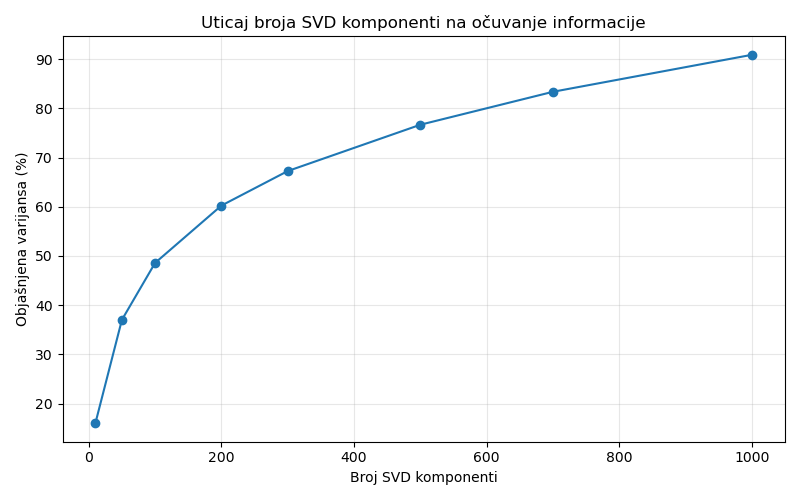

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    summary_df["Broj komponenti"].to_numpy(),
    summary_df["Objašnjena varijansa (%)"].to_numpy(),
    marker="o"
)

plt.xlabel("Broj SVD komponenti")
plt.ylabel("Objašnjena varijansa (%)")
plt.title("Uticaj broja SVD komponenti na očuvanje informacije")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
#Primena modela
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve, 
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [13]:
#Multionimial Naive Bayes-ceo skup

# Kreiranje Multinomial Naive Bayes klasifikatora
nb_model = MultinomialNB()

# Treniranje modela
nb_model.fit(X_train_tfidf, y_train)

# Predikcija nad test skupom
y_pred_nb = nb_model.predict(X_test_tfidf)

print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_nb):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_nb):.3f}")

cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

report = classification_report(
    y_test, 
    y_pred_nb, 
    output_dict=True
)

pd.DataFrame(report).T.iloc[:2]

Accuracy : 0.877
Precision: 0.832
Recall   : 0.964
F1-score : 0.893
[[301  86]
 [ 16 426]]


,precision,recall,f1-score,support
-1,0.949527,0.777778,0.855114,387.0
1,0.832031,0.963801,0.893082,442.0


In [14]:
#Multionimial Naive Bayes-chi2 

chi2_results_nb = []

for k in chi2_train.keys():

    X_train = chi2_train[k]
    X_test = chi2_test[k]

    # kreiranje i treniranje modela
    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)

    # predikcija
    y_pred = nb_model.predict(X_test)

    # čuvanje rezultata
    chi2_results_nb.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })


# kreiranje tabele
chi2_results_nb_df = pd.DataFrame(chi2_results_nb)


# sortiranje po k
chi2_results_nb_df = chi2_results_nb_df.sort_values("k")


# formatiranje na 3 decimale
chi2_results_nb_df = chi2_results_nb_df.round(3)


chi2_results_nb_df

,k,Accuracy,Precision,Recall,F1-score
0,10,0.723,0.662,0.980,0.790
1,100,0.844,0.795,0.955,0.867
2,500,0.860,0.812,0.959,0.880
3,1000,0.873,0.823,0.971,0.891
4,3000,0.881,0.832,0.973,0.897
5,5000,0.879,0.834,0.966,0.895
6,10000,0.881,0.837,0.964,0.896
7,20000,0.881,0.837,0.964,0.896


In [15]:
#LinearSVM-ceo skup
# Kreiranje LinearSVC modela

svm_model = LinearSVC()

# Treniranje
svm_model.fit(X_train_tfidf, y_train)

# Predikcija
y_pred_svm = svm_model.predict(X_test_tfidf)


print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_svm):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_svm):.3f}")

report = classification_report(
    y_test, 
    y_pred_svm, 
    output_dict=True
)
pd.DataFrame(report).T.iloc[:2]

Accuracy : 0.907
Precision: 0.892
Recall   : 0.939
F1-score : 0.915


,precision,recall,f1-score,support
-1,0.925824,0.870801,0.897470,387.0
1,0.892473,0.938914,0.915105,442.0


In [16]:
#LinearSVM-chi2

svm_chi2_results = []

for k in chi2_train.keys():

    # uzimanje chi2 redukovanih podataka
    X_train_chi = chi2_train[k]
    X_test_chi = chi2_test[k]

    # kreiranje modela
    svm_model = LinearSVC()

    # treniranje
    svm_model.fit(X_train_chi, y_train)

    # predikcija
    y_pred = svm_model.predict(X_test_chi)

    # čuvanje rezultata
    svm_chi2_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })


# kreiranje tabele
svm_chi2_df = pd.DataFrame(svm_chi2_results)

# zaokruživanje
svm_chi2_df = svm_chi2_df.round(3)

svm_chi2_df

,k,Accuracy,Precision,Recall,F1-score
0,10,0.756,0.694,0.971,0.809
1,100,0.859,0.810,0.962,0.879
2,500,0.876,0.841,0.946,0.890
3,1000,0.893,0.861,0.952,0.904
4,3000,0.907,0.892,0.939,0.915
5,5000,0.903,0.895,0.928,0.911
6,10000,0.901,0.893,0.925,0.909
7,20000,0.908,0.893,0.941,0.916


In [17]:
#LinearSVM-TruncatedSVD
svm_svd_results = []

for components in svd_train.keys():

    # uzimanje SVD redukovanih podataka
    X_train_svd = svd_train[components]
    X_test_svd = svd_test[components]

    # kreiranje modela
    svm_model = LinearSVC()

    # treniranje
    svm_model.fit(X_train_svd, y_train)

    # predikcija
    y_pred = svm_model.predict(X_test_svd)

    # čuvanje rezultata
    svm_svd_results.append({
        "components": components,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })


# tabela rezultata
svm_svd_df = pd.DataFrame(svm_svd_results)

# zaokruživanje
svm_svd_df = svm_svd_df.round(3)

svm_svd_df

,components,Accuracy,Precision,Recall,F1-score
0,10,0.837,0.802,0.923,0.858
1,50,0.856,0.822,0.932,0.874
2,100,0.870,0.842,0.930,0.884
3,200,0.889,0.866,0.937,0.900
4,300,0.896,0.874,0.941,0.906
5,500,0.901,0.893,0.925,0.909
6,700,0.900,0.886,0.932,0.908
7,1000,0.895,0.882,0.928,0.904


In [18]:
#KNN-ceo skup

knn_results = []


neighbors = [1, 3, 5, 7, 10, 15, 20]

for n in neighbors:

    knn_model = KNeighborsClassifier(n_neighbors=n)

    knn_model.fit(X_train_tfidf, y_train)

    y_pred = knn_model.predict(X_test_tfidf)

    knn_results.append({
        "neighbors": n,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })


knn_df = pd.DataFrame(knn_results)

knn_df.round(3)

,neighbors,Accuracy,Precision,Recall,F1-score
0,1,0.881,0.870,0.912,0.891
1,3,0.885,0.862,0.934,0.897
2,5,0.885,0.862,0.934,0.897
3,7,0.866,0.843,0.921,0.880
4,10,0.862,0.846,0.907,0.876
5,15,0.854,0.827,0.919,0.870
6,20,0.852,0.822,0.921,0.869


In [19]:
#KNN-chi2

neighbors = [1, 3, 5, 7, 10, 15, 20]

knn_chi2_results = []

for k in chi2_train.keys():

    best_result = None

    for n in neighbors:

        model = KNeighborsClassifier(n_neighbors=n)

        model.fit(chi2_train[k], y_train)

        y_pred = model.predict(chi2_test[k])

        result = {
            "k": k,
            "neighbors": n,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        }

        if best_result is None or result["F1-score"] > best_result["F1-score"]:
            best_result = result

    knn_chi2_results.append(best_result)

knn_chi2_df = pd.DataFrame(knn_chi2_results).round(3)

knn_chi2_df

,k,neighbors,Accuracy,Precision,Recall,F1-score
0,10,7,0.770,0.714,0.948,0.814
1,100,5,0.855,0.837,0.905,0.870
2,500,5,0.856,0.850,0.887,0.868
3,1000,5,0.850,0.846,0.880,0.863
4,3000,1,0.835,0.907,0.769,0.832
5,5000,5,0.846,0.849,0.864,0.857
6,10000,5,0.821,0.764,0.962,0.852
7,20000,7,0.858,0.823,0.934,0.875


In [20]:
#KNN-TruncatedSVD

neighbors = [1, 3, 5, 7, 10, 15, 20]

knn_svd_results = []

for components in svd_train.keys():

    best_result = None

    for n in neighbors:

        model = KNeighborsClassifier(n_neighbors=n)

        model.fit(svd_train[components], y_train)

        y_pred = model.predict(svd_test[components])

        result = {
            "components": components,
            "neighbors": n,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        }

        if best_result is None or result["F1-score"] > best_result["F1-score"]:
            best_result = result

    knn_svd_results.append(best_result)

knn_svd_df = pd.DataFrame(knn_svd_results)
knn_svd_df = knn_svd_df.round(3)

knn_svd_df

,components,neighbors,Accuracy,Precision,Recall,F1-score
0,10,5,0.852,0.834,0.900,0.866
1,50,7,0.876,0.863,0.912,0.887
2,100,7,0.879,0.870,0.910,0.889
3,200,1,0.870,0.888,0.864,0.876
4,300,1,0.876,0.910,0.851,0.880
5,500,1,0.848,0.916,0.787,0.847
6,700,5,0.890,0.882,0.916,0.899
7,1000,5,0.885,0.862,0.934,0.897


In [21]:
#decision tree-ceo skup

dt_results = []

depths = [3, 5, 10, 15, 20, None]

for depth in depths:

    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt_model.fit(X_train_tfidf, y_train)

    y_pred = dt_model.predict(X_test_tfidf)

    dt_results.append({
        "max_depth": depth,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

dt_df = pd.DataFrame(dt_results)

dt_df.round(3)

,max_depth,Accuracy,Precision,Recall,F1-score
0,3.0,0.749,0.688,0.968,0.805
1,5.0,0.791,0.730,0.966,0.832
2,10.0,0.831,0.778,0.957,0.858
3,15.0,0.835,0.790,0.939,0.858
4,20.0,0.828,0.791,0.919,0.850
5,NaN,0.825,0.831,0.844,0.837


In [22]:
#decision tree-chi2

depths = [3, 5, 10, 15, 20, None]

dt_results = []

for depth in depths:

    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt_model.fit(X_train_tfidf, y_train)

    y_pred = dt_model.predict(X_test_tfidf)

    dt_results.append({
        "max_depth": depth,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

dt_df = pd.DataFrame(dt_results)
dt_df = dt_df.round(3)

dt_df

,max_depth,Accuracy,Precision,Recall,F1-score
0,3.0,0.749,0.688,0.968,0.805
1,5.0,0.791,0.730,0.966,0.832
2,10.0,0.831,0.778,0.957,0.858
3,15.0,0.835,0.790,0.939,0.858
4,20.0,0.828,0.791,0.919,0.850
5,NaN,0.825,0.831,0.844,0.837


In [23]:
#decision tree-chi2

depths = [3, 5, 10, 15, 20, None]

dt_chi2_results = []

for k in chi2_train.keys():

    best_result = None

    for depth in depths:

        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )

        model.fit(chi2_train[k], y_train)

        y_pred = model.predict(chi2_test[k])

        result = {
            "k": k,
            "max_depth": depth,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        }

        if best_result is None or result["F1-score"] > best_result["F1-score"]:
            best_result = result

    dt_chi2_results.append(best_result)

dt_chi2_df = pd.DataFrame(dt_chi2_results)
dt_chi2_df = dt_chi2_df.round(3)

dt_chi2_df

,k,max_depth,Accuracy,Precision,Recall,F1-score
0,10,NaN,0.767,0.709,0.955,0.814
1,100,NaN,0.847,0.837,0.885,0.860
2,500,NaN,0.861,0.852,0.896,0.873
3,1000,10.0,0.838,0.789,0.950,0.862
4,3000,10.0,0.837,0.788,0.950,0.862
5,5000,15.0,0.840,0.793,0.946,0.863
6,10000,10.0,0.835,0.781,0.959,0.861
7,20000,15.0,0.834,0.790,0.937,0.857


In [24]:
#decision tree-TruncatedSVD

depths = [3, 5, 10, 15, 20, None]

dt_svd_results = []

for components in svd_train.keys():

    best_result = None

    for depth in depths:

        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )

        model.fit(svd_train[components], y_train)

        y_pred = model.predict(svd_test[components])

        result = {
            "components": components,
            "max_depth": depth,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        }

        if best_result is None or result["F1-score"] > best_result["F1-score"]:
            best_result = result

    dt_svd_results.append(best_result)

dt_svd_df = pd.DataFrame(dt_svd_results)
dt_svd_df = dt_svd_df.round(3)

dt_svd_df

,components,max_depth,Accuracy,Precision,Recall,F1-score
0,10,15.0,0.841,0.841,0.864,0.853
1,50,20.0,0.844,0.847,0.864,0.856
2,100,15.0,0.849,0.845,0.878,0.861
3,200,5.0,0.840,0.813,0.907,0.858
4,300,15.0,0.848,0.832,0.896,0.863
5,500,20.0,0.853,0.854,0.873,0.864
6,700,20.0,0.856,0.858,0.876,0.867
7,1000,NaN,0.850,0.835,0.896,0.865


In [25]:
#Logistic Regression-ceo skup

# Kreiranje modela
lr_model = LogisticRegression(max_iter=1000)

# Treniranje
lr_model.fit(X_train_tfidf, y_train)

# Predikcija
y_pred_lr = lr_model.predict(X_test_tfidf)


print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_lr):.3f}")


report = classification_report(
    y_test, 
    y_pred_lr, 
    output_dict=True
)
pd.DataFrame(report).T.iloc[:2]

Accuracy : 0.899
Precision: 0.868
Recall   : 0.955
F1-score : 0.909


,precision,recall,f1-score,support
-1,0.941691,0.834625,0.884932,387.0
1,0.868313,0.954751,0.909483,442.0


In [26]:
#Logistic Regresssion-chi2


lr_chi2_results = []

for k in chi2_train.keys():

    # uzimanje redukovanih podataka
    X_train_chi = chi2_train[k]
    X_test_chi = chi2_test[k]

    # kreiranje modela
    lr_model = LogisticRegression(max_iter=1000)

    # treniranje
    lr_model.fit(X_train_chi, y_train)

    # predikcija
    y_pred = lr_model.predict(X_test_chi)

    # čuvanje rezultata
    lr_chi2_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })


# pravljenje tabele
lr_chi2_df = pd.DataFrame(lr_chi2_results)

# zaokruživanje
lr_chi2_df = lr_chi2_df.round(3)

lr_chi2_df

,k,Accuracy,Precision,Recall,F1-score
0,10,0.739,0.679,0.971,0.799
1,100,0.837,0.783,0.962,0.863
2,500,0.871,0.823,0.966,0.889
3,1000,0.879,0.837,0.962,0.895
4,3000,0.894,0.863,0.952,0.905
5,5000,0.897,0.865,0.957,0.909
6,10000,0.891,0.861,0.950,0.903
7,20000,0.894,0.863,0.952,0.905


In [27]:
#Logistic regresion-TruncatedSVD
lr_svd_results = []

for components in svd_train.keys():

    # uzimanje SVD redukovanih podataka
    X_train_svd = svd_train[components]
    X_test_svd = svd_test[components]

    # kreiranje modela
    lr_model = LogisticRegression(max_iter=1000)

    # treniranje
    lr_model.fit(X_train_svd, y_train)

    # predikcija
    y_pred = lr_model.predict(X_test_svd)

    # čuvanje rezultata
    lr_svd_results.append({
        "components": components,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })


# tabela rezultata
lr_svd_df = pd.DataFrame(lr_svd_results)

# zaokruživanje
lr_svd_df = lr_svd_df.round(3)

lr_svd_df

,components,Accuracy,Precision,Recall,F1-score
0,10,0.826,0.794,0.910,0.848
1,50,0.844,0.803,0.939,0.865
2,100,0.858,0.825,0.930,0.874
3,200,0.885,0.852,0.950,0.898
4,300,0.897,0.864,0.959,0.909
5,500,0.890,0.862,0.946,0.902
6,700,0.895,0.863,0.955,0.907
7,1000,0.896,0.865,0.955,0.908


In [28]:
# Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(chi2_train[3000], y_train)

# LinearSVC
svm_model = LinearSVC()
svm_model.fit(chi2_train[3000], y_train)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_model.fit(chi2_train[500], y_train)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(svd_train[700], y_train)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(svd_train[300], y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


<IPython.core.display.Javascript object>


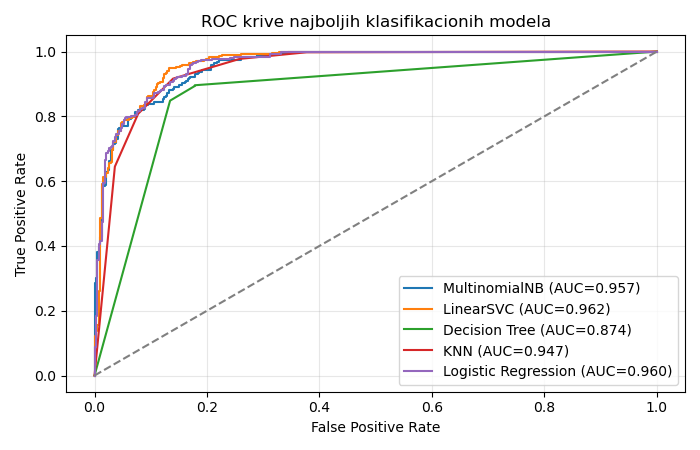

In [31]:
plt.close("all")
fig, ax = plt.subplots(figsize=(7, 4.5))

# ---------- Multinomial NB ----------
scores = nb_model.predict_proba(chi2_test[3000])[:,1]
fpr, tpr, _ = roc_curve(y_test, scores)
auc = roc_auc_score(y_test, scores)
ax.plot(fpr, tpr, label=f"MultinomialNB (AUC={auc:.3f})")


# ---------- LinearSVC ----------
scores = svm_model.decision_function(chi2_test[3000])
fpr, tpr, _ = roc_curve(y_test, scores)
auc = roc_auc_score(y_test, scores)
ax.plot(fpr, tpr, label=f"LinearSVC (AUC={auc:.3f})")


# ---------- Decision Tree ----------
scores = dt_model.predict_proba(chi2_test[500])[:,1]
fpr, tpr, _ = roc_curve(y_test, scores)
auc = roc_auc_score(y_test, scores)
ax.plot(fpr, tpr, label=f"Decision Tree (AUC={auc:.3f})")


# ---------- KNN ----------
scores = knn_model.predict_proba(svd_test[700])[:,1]
fpr, tpr, _ = roc_curve(y_test, scores)
auc = roc_auc_score(y_test, scores)
ax.plot(fpr, tpr, label=f"KNN (AUC={auc:.3f})")


# ---------- Logistic Regression ----------
scores = lr_model.predict_proba(svd_test[300])[:,1]
fpr, tpr, _ = roc_curve(y_test, scores)
auc = roc_auc_score(y_test, scores)
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc:.3f})")


# dijagonala
ax.plot([0,1], [0,1], '--', color='gray')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC krive najboljih klasifikacionih modela")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
#analiza najboljeg modela


# uzimanje najboljeg chi2 skupa
k=3000
X_train_best = chi2_train[k]
X_test_best = chi2_test[k]

# kreiranje najboljeg modela
best_svm_model = LinearSVC()

# treniranje
best_svm_model.fit(X_train_best, y_train)

# predikcija
y_pred_best = best_svm_model.predict(X_test_best)

# metrike
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_best):.3f}")


Accuracy : 0.907
Precision: 0.892
Recall   : 0.939
F1-score : 0.915


In [33]:
# classification report
report = classification_report(
    y_test,
    y_pred_best,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.round(2)

,precision,recall,f1-score,support
-1,0.93,0.87,0.90,387.00
1,0.89,0.94,0.92,442.00
accuracy,0.91,0.91,0.91,0.91
macro avg,0.91,0.90,0.91,829.00
weighted avg,0.91,0.91,0.91,829.00


<IPython.core.display.Javascript object>


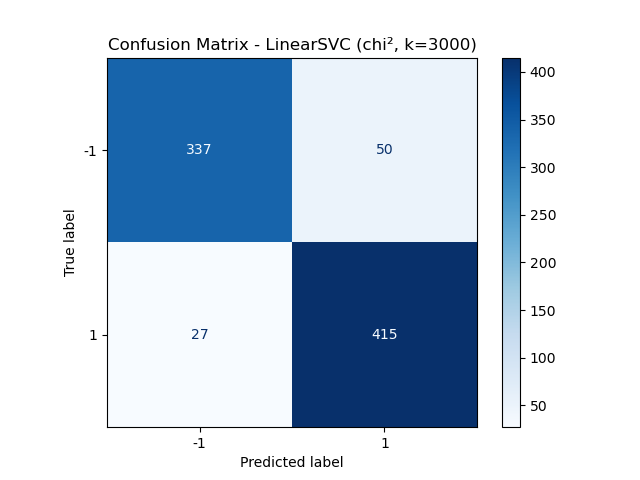

In [34]:
# confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_svm_model,
    X_test_best,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - LinearSVC (chi², k=3000)")
plt.show()


In [35]:
# nazivi izabranih atributa
selected_features = chi2_features[3000]

# koeficijenti LinearSVC
coefficients = best_svm_model.coef_[0]

feature_importance = pd.DataFrame({
    "Reč": selected_features,
    "Koeficijent": coefficients
})


top_positive = (
    feature_importance
    .sort_values("Koeficijent", ascending=False)
    .head(10)
)

top_positive

,Reč,Koeficijent
1500,horse,1.784597
711,cattle,1.756768
2168,probiotic,1.613015
2069,pet,1.562404
1740,livestock,1.501905
284,ad-pet,1.337122
474,animal,1.333957
2916,veterinary,1.319431
657,bunny,1.298793
1202,fitness,1.267540


In [36]:
top_negative = (
    feature_importance
    .sort_values("Koeficijent", ascending=True)
    .head(10)
)

top_negative

,Reč,Koeficijent
2034,patient,-1.891010
48,ad-baby,-1.617320
2828,treatment,-1.593516
543,baby,-1.458196
298,ad-print,-1.426746
2594,system,-1.426356
105,ad-commodity,-1.379295
2611,technology,-1.258499
2886,usa,-1.238405
676,cambridge,-1.206565


In [37]:
#cross validation

from sklearn.model_selection import cross_val_score

svm_cv = LinearSVC()

cv_scores = cross_val_score(
    svm_cv,
    X_train_best,
    y_train,
    cv=5,
    scoring="f1"
)

cv_results = pd.DataFrame({
    "Fold": range(1, 6),
    "F1-score": cv_scores
})

cv_results.loc[len(cv_results)] = ["Prosek", cv_scores.mean()]

cv_results


,Fold,F1-score
0,1,0.911846
1,2,0.932414
2,3,0.920502
3,4,0.917483
4,5,0.939691
5,Prosek,0.924387
